In [10]:
# Install required packages silently
install.packages(
  c("readxl", "tidyquery"),
  quiet = TRUE,
  verbose = FALSE,
  INSTALL_opts = "--no-test-load"
)

also installing the dependency ‘queryparser’




In [15]:
library(readxl)
library(tidyr)
library(tidyquery)
library(ggplot2)


##### Load the dataset

In [12]:
ghg_df <- read_xlsx(path = "sample_data/EDGAR_2025_GHG_booklet_2025.xlsx", sheet ="GHG_totals_by_country")

head(ghg_df, 5)

EDGAR Country Code,Country,1970,1971,1972,1973,1974,1975,1976,1977,⋯,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ABW,Aruba,3.696956e-02,4.182524e-02,5.270835e-02,5.770431e-02,5.699943e-02,0.07113402,7.020048e-02,8.104540e-02,⋯,0.49151643,0.51507336,0.4966883,0.49496692,0.54001349,0.51908073,0.53833480,0.56749203,0.56950279,0.58871640
AFG,Afghanistan,1.529996e+01,1.522108e+01,1.327875e+01,1.397205e+01,1.524200e+01,15.96887186,1.612456e+01,1.618778e+01,⋯,28.09308462,27.16474141,30.4745948,31.93581042,32.43616845,32.40016796,32.83584592,31.91213908,32.43510674,33.03484009
AGO,Angola,1.883435e+01,1.872185e+01,2.131678e+01,2.287876e+01,2.358610e+01,22.42177222,1.846445e+01,2.313262e+01,⋯,83.53685786,80.62550776,75.4336427,70.46511603,71.20874944,63.15922110,66.60191942,68.03523704,68.28078505,69.92293878
AIA,Anguilla,3.397521e-03,3.447974e-03,3.594584e-03,3.480455e-03,3.770682e-03,0.00405093,3.920464e-03,4.052565e-03,⋯,0.03141767,0.03181268,0.0325607,0.03168205,0.03103668,0.02612483,0.02531381,0.02515586,0.02515758,0.02603517
AIR,International Aviation,1.724780e+02,1.724654e+02,1.824598e+02,1.902969e+02,1.831621e+02,177.16583437,1.774831e+02,1.935934e+02,⋯,543.59604085,567.90592566,597.7333715,623.93239847,633.21705347,299.63633431,330.74840749,477.75147796,578.33073648,622.33416208


#### Reshape the data (Pivot from wide to long)

In [13]:
melted_df <- ghg_df %>%
  pivot_longer(
    cols = `1970`:`2024`,
    names_to = "Year",
    values_to = "GHG_Total"
  )

# # Ensure Year is numeric for the x-axis
melted_df$Year <- as.integer(melted_df$Year)

head(melted_df, 5)

EDGAR Country Code,Country,Year,GHG_Total
<chr>,<chr>,<int>,<dbl>
ABW,Aruba,1970,0.03696956
ABW,Aruba,1971,0.04182524
ABW,Aruba,1972,0.05270835
ABW,Aruba,1973,0.05770431
ABW,Aruba,1974,0.05699943


#### # Filter top 10 countries by GHG emissions

In [14]:
# Using tidyquery (Direct SQL on R Data Frames)

df_top_10_countries_by_ghg <- query("
  SELECT Country, SUM(GHG_Total) AS GHG_Total
  FROM melted_df
  WHERE Country NOT IN ('GLOBAL TOTAL', 'EU27')
  GROUP BY Country
  ORDER BY GHG_Total DESC
  LIMIT 10
")

df_top_10_countries_by_ghg

Country,GHG_Total
<chr>,<dbl>
China,373558.54
United States,349160.18
Russia,127331.84
India,108415.66
Japan,68196.11
Germany,60537.61
Brazil,45796.85
United Kingdom,38176.32
Canada,36420.93


In [31]:
# # Select specific countries and extract list
#countries_to_plot <- df_top_10_countries_by_ghg$Country
countries_to_plot <- as.list(df_top_10_countries_by_ghg$Country)
countries_to_plot

[1] "China"          "United States"  "Russia"         "India"         
 [5] "Japan"          "Germany"        "Brazil"         "United Kingdom"
 [9] "Canada"         "Ukraine"

In [38]:
filtered_df <- melted_df[melted_df$Country %in% countries_to_plot, ]

print(dim(ghg_df))
print(dim(melted_df))
print(dim(filtered_df))


[1] 214  57
[1] 11770     4
[1] 550   4


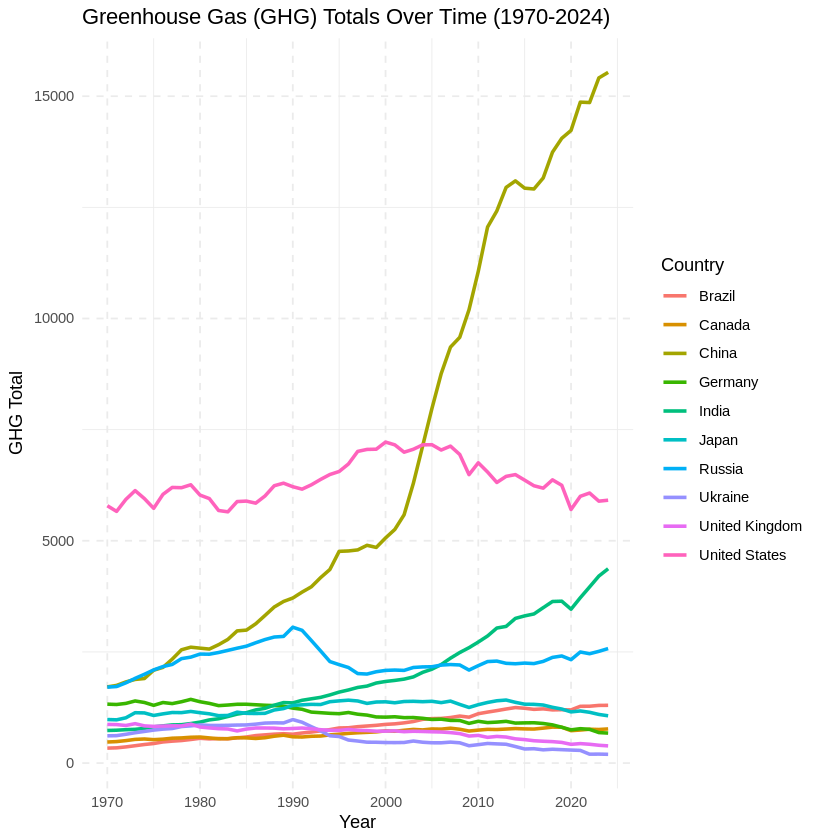

In [53]:
library(ggplot2)

# 5. Create the plot and 6. Customize the chart
plot <- ggplot(filtered_df, aes(x = Year, y = GHG_Total, color = Country)) +
  geom_line(linewidth = 1) +
  labs(
    title = "Greenhouse Gas (GHG) Totals Over Time (1970-2024)",
    x = "Year",
    y = "GHG Total",
    color = "Country"
  ) +
  theme_minimal() +
  theme(
    panel.grid.major = element_line(linetype = "dashed")
  )

# 7. Display or save the result
plot

ggsave("ghg_line_chart.png", plot = p, width=12, height=6, dpi=300)

